In [2]:
import pandas as pd


In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().copy()

In [7]:
df['Churn'] = df['Churn'].replace({'Yes' : 1, 'No' : 0})

C:\Users\torit\AppData\Local\Temp\ipykernel_12776\2455774617.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes' : 1, 'No' : 0})


In [8]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [10]:
df = df.reset_index(drop=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [12]:
import sqlite3

In [13]:
conn = sqlite3.connect('churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

7032

In [14]:
query= '''
SELECT churn, AVG(MonthlyCharges) as 
avg_charge
FROM customers
GROUP BY Churn
'''
import pandas as pd
pd.read_sql(query, conn)

,Churn,avg_charge
0,0,61.307408
1,1,74.441332


In [15]:
query='''
SELECT Churn, COUNT(*)
FROM customers
GROUP BY Churn
'''
import pandas as pd
pd.read_sql(query, conn)


,Churn,COUNT(*)
0,0,5163
1,1,1869


In [16]:
query = '''
SELECT Churn, AVG(tenure)
FROM customers
GROUP BY Churn
'''
import pandas as pd 
pd.read_sql(query, conn)

,Churn,AVG(tenure)
0,0,37.650010
1,1,17.979133


In [17]:
query = '''
SELECT Contract, Churn, COUNT(*)
FROM customers
GROUP BY Contract, Churn
'''
import pandas as pd
pd.read_sql(query, conn)

,Contract,Churn,COUNT(*)
0,Month-to-month,0,2220
1,Month-to-month,1,1655
2,One year,0,1306
3,One year,1,166
4,Two year,0,1637
5,Two year,1,48


In [18]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

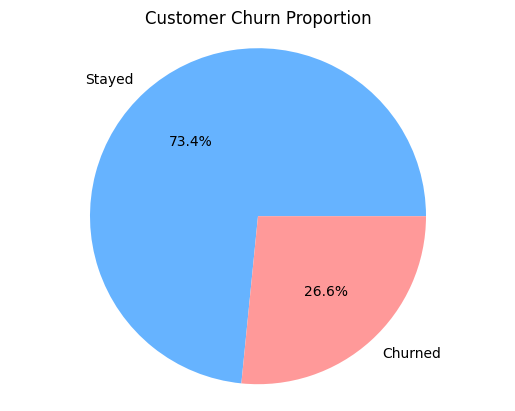

In [19]:
import matplotlib.pyplot as plt
#Data from your value_counts()
churn_data = df['Churn'].value_counts()
plt.pie(churn_data, labels=['Stayed', 'Churned'],autopct='%1.1f%%',
colors = ['#66b3ff','#ff9999'])
plt.title('Customer Churn Proportion')
plt.axis('equal') #Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

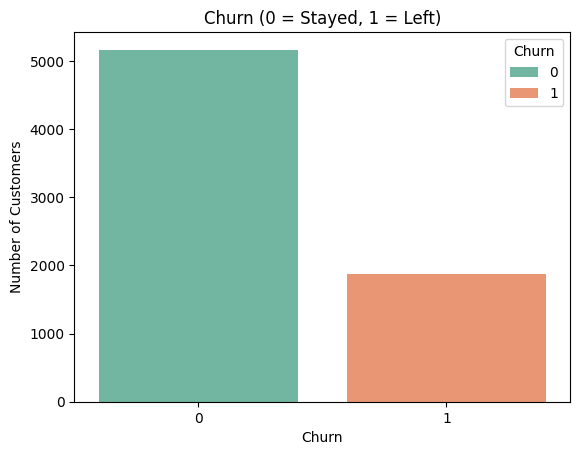

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Churn', data=df,hue='Churn', palette='Set2')
plt.title('Count of Customers(Stayed vs. Churned)')
plt.title('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')
plt.show()

In [21]:
df.groupby('Churn')['tenure'].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

In [22]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

In [23]:
df.groupby(['Contract','Churn']).size().unstack()

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [24]:
df.groupby(['InternetService', 'Churn']).size().unstack()

Churn,0,1
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [25]:
df.groupby(['PaymentMethod','Churn']).size().unstack()

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


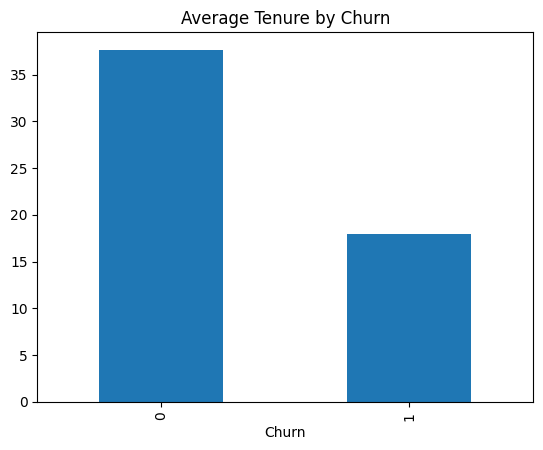

In [26]:
import matplotlib.pyplot as plt

df.groupby('Churn')['tenure'].mean().plot(kind='bar')
plt.title('Average Tenure by Churn')
plt.show()

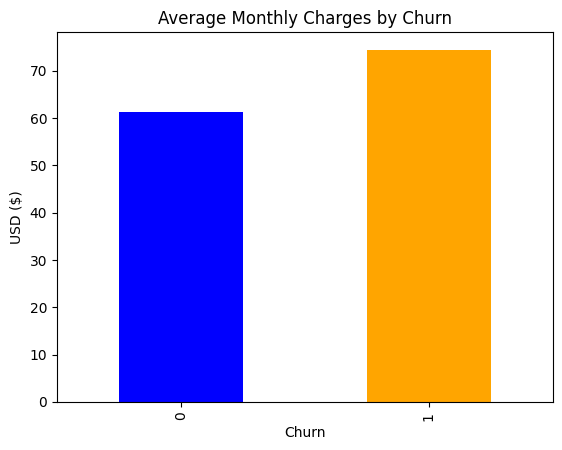

In [27]:
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar',color=['blue', 'orange'])
plt.title('Average Monthly Charges by Churn')
plt.ylabel('USD ($)')
plt.show()

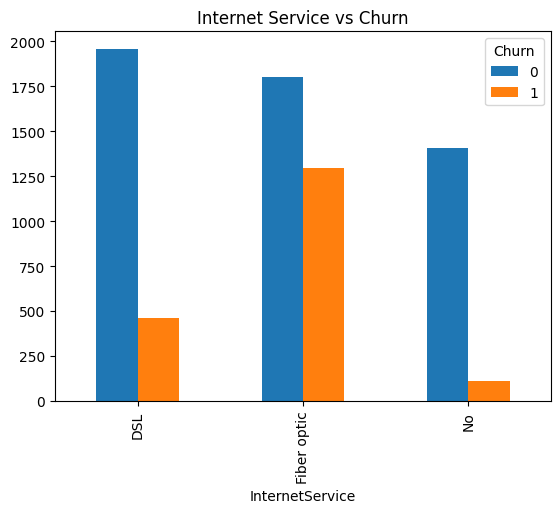

In [28]:
df.groupby(['InternetService', 'Churn']).size().unstack().plot(kind='bar')
plt.title('Internet Service vs Churn')
plt.show()

In [29]:
df.drop('customerID', axis=1, inplace=True, errors='ignore')

In [30]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [31]:
df = pd.get_dummies(df, drop_first=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  Inte

In [33]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
Y = df['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [34]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=3000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=3000)

In [35]:
from sklearn.metrics import classification_report, accuracy_score
pred = model.predict(X_test)
print(accuracy_score(Y_test, pred))
print(classification_report(Y_test, pred))

0.8031272210376688
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       372

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



In [36]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, Y_train)

RandomForestClassifier()

In [37]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [38]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Y_test, pred))

[[926 109]
 [168 204]]


In [39]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(class_weight='balanced',max_iter=3000)
model_lr.fit(X_train, Y_train)

pred_lr = model_lr.predict(X_test)

In [40]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train, Y_train)

pred_rf = model_rf.predict(X_test)

In [41]:
from sklearn.metrics import classification_report
print('Logistic Regression:\n', classification_report(Y_test, pred_lr))
print('Random Forest:\n', classification_report(Y_test, pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.92      0.72      0.80      1035
           1       0.51      0.81      0.63       372

    accuracy                           0.74      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.74      0.76      1407

Random Forest:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       372

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [42]:
import pandas as pd
importance = pd.Series(model_rf.feature_importances_,
                       index=X.columns)
importance.sort_values(ascending=False).head(10)

TotalCharges                      0.198222
tenure                            0.172642
MonthlyCharges                    0.165044
InternetService_Fiber optic       0.041882
PaymentMethod_Electronic check    0.036931
Contract_Two year                 0.030995
gender_Male                       0.028884
PaperlessBilling_Yes              0.026612
OnlineSecurity_Yes                0.024268
Contract_One year                 0.023797
dtype: float64